In [1]:
import pandas as pd
import pickle
import shap
import json
import numpy as np

In [2]:
import os
import sys
device = "cuda"

project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

In [3]:
from classification.utils_finetune import load_dataset, split_dataset

In [4]:
with open(project_root + "/params.json", 'r') as f:
    PARAMS = json.load(f)

In [5]:
df = pd.read_csv(project_root + "/xai/data/invariance_dataset.csv")

In [6]:
model_id = project_root + "/classification/regression_model/regression_model.pkl"
dataset = load_dataset()
print(f"Size of dataset: {len(dataset)}")
labels = list(dataset["label"].unique())
label2id, id2label, train_data, _, _ = split_dataset(dataset, labels, train_size=PARAMS["train_split"], val_size=PARAMS["val_split"])


Cleaning text


100%|██████████| 3067/3067 [00:00<00:00, 31122.14it/s]

Size of dataset: 3067
{'HIGH': 0, 'MEDIUM': 1, 'LOW': 2}
{0: 'HIGH', 1: 'MEDIUM', 2: 'LOW'}


In [7]:
from xai.utils import get_tokenizer, predict_proba, print_attr, merge_tokens, group_values, get_class_contribs

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [8]:
loaded_model_reg = pickle.load(open(model_id, 'rb'))
vectorizer = pickle.load(open(project_root + "/classification/regression_model/vectorizer.pkl", 'rb'))
X_train = vectorizer.transform(list(train_data["text"])).toarray()

tokenizer = get_tokenizer()


In [9]:
df

,text,newOBJECTID,real,port_label,popular,true_label
0,For Alexandria is approached by a treacherous ...,12,1,LOW,1,HIGH
1,For Neapolis is approached by a treacherous ha...,129,0,LOW,1,HIGH
2,For Rhacotis is approached by a treacherous ha...,11,0,HIGH,1,HIGH
3,For Herculaneum is approached by a treacherous...,131,0,LOW,0,HIGH
4,For Rhoda is approached by a treacherous harbo...,0,0,HIGH,0,HIGH
5,sacrificing in the temple of Castor and Pollux...,93,1,LOW,1,LOW
6,sacrificing in the temple of Castor and Pollux...,0,0,HIGH,0,LOW
7,sacrificing in the temple of Castor and Pollux...,11,0,HIGH,1,LOW
8,sacrificing in the temple of Castor and Pollux...,131,0,LOW,0,LOW
9,sacrificing in the temple of Castor and Pollux...,129,0,LOW,1,LOW


In [10]:
sample_texts = list(df["text"])

In [11]:
roberta_explainer = shap.Explainer(
    predict_proba,
    tokenizer,
    output_names=["LOW", "MEDIUM", "HIGH"],  
    silent=True
)

logistic_explainer = shap.LinearExplainer(loaded_model_reg, X_train, silent=True)

In [12]:
shap_roberta = roberta_explainer(sample_texts)

In [13]:
sample_texts_vect = vectorizer.transform(sample_texts).toarray()

shap_linear = logistic_explainer(sample_texts_vect)

In [14]:
predicted_labels_roberta = np.argmax(roberta_explainer.model(sample_texts), axis=1)

In [15]:
predicted_labels_regression = np.argmax(roberta_explainer.model(sample_texts), axis=1)

In [16]:
data = [tokenizer.tokenize(x) for x in sample_texts]

In [17]:
df["label_reg"] = [id2label[x] for x in predicted_labels_regression]
df["label_roberta"] = [id2label[x] for x in predicted_labels_roberta]

In [18]:
df["text"][0]

'For Alexandria is approached by a treacherous harbour, with deceptive shallows and uncertain seas'

In [19]:
df["text"][9]

'sacrificing in the temple of Castor and Pollux at Neapolis, a calm smoothed the sea, the wind changed to a gentle southern breeze, and the ships entered the harbour under full sail and again crammed the storehouses with grain.'

In [20]:
roberta_contribs, roberta_contexts = get_class_contribs(data, shap_roberta.values, group=1)

In [21]:
df

,text,newOBJECTID,real,port_label,popular,true_label,label_reg,label_roberta
0,For Alexandria is approached by a treacherous ...,12,1,LOW,1,HIGH,HIGH,HIGH
1,For Neapolis is approached by a treacherous ha...,129,0,LOW,1,HIGH,LOW,LOW
2,For Rhacotis is approached by a treacherous ha...,11,0,HIGH,1,HIGH,HIGH,HIGH
3,For Herculaneum is approached by a treacherous...,131,0,LOW,0,HIGH,LOW,LOW
4,For Rhoda is approached by a treacherous harbo...,0,0,HIGH,0,HIGH,HIGH,HIGH
5,sacrificing in the temple of Castor and Pollux...,93,1,LOW,1,LOW,LOW,LOW
6,sacrificing in the temple of Castor and Pollux...,0,0,HIGH,0,LOW,HIGH,HIGH
7,sacrificing in the temple of Castor and Pollux...,11,0,HIGH,1,LOW,LOW,LOW
8,sacrificing in the temple of Castor and Pollux...,131,0,LOW,0,LOW,LOW,LOW
9,sacrificing in the temple of Castor and Pollux...,129,0,LOW,1,LOW,LOW,LOW


In [22]:
import numpy as np

def merge_roberta_tokens(tokens, scores):

    merged_tokens = []
    merged_scores = []

    current_token = ""
    current_scores = []

    for token, score in zip(tokens, scores):

        # new word starts
        if token.startswith("▁"):

            # save previous word
            if current_token:
                merged_tokens.append(current_token)
                merged_scores.append(np.mean(current_scores))

            # start new word
            current_token = token.replace("▁", "")
            current_scores = [score]

        else:
            # continue subword
            current_token += token
            current_scores.append(score)

    # add final token
    if current_token:
        merged_tokens.append(current_token)
        merged_scores.append(np.mean(current_scores))

    return merged_tokens, np.array(merged_scores)

In [23]:
import matplotlib.pyplot as plt
import numpy as np


def plot_token_attributions(
    title,
    tokens,
    scores,
    figsize=(14, 2),
    positive_color="#008000", #green
    negative_color="#ff4d4d", #red
    neutral_color="#f2f2f2",  #beige
    normalize=True,
    spacing=0.03,
    fontsize=11
):
    scores = np.array(scores)
    if normalize:
        max_abs = np.max(np.abs(scores))
        if max_abs > 0:
            scores = scores / max_abs

    fig, ax = plt.subplots(figsize=figsize, dpi=120)
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    p0 = ax.transData.transform((0, 0))
    p1 = ax.transData.transform((1, 0))
    px_per_data = p1[0] - p0[0]
    
    x = 0
    y = 0.4
    
    for token, score in zip(tokens, scores):
        if score > 0:
            alpha = min(abs(score), 1.0)
            color = positive_color
        elif score < 0:
            alpha = min(abs(score), 1.0)
            color = negative_color
        else:
            alpha = 0.15
            color = neutral_color


        txt = ax.text(
            x, y, 
            token,
            fontsize=fontsize,
            ha="left",
            va="center",
            transform=ax.transData,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor=color,
                edgecolor="none",
                alpha=alpha
            ),
            color="black"
        )

        fig.canvas.draw()
        bbox = txt.get_window_extent(renderer=renderer)
        width_axes = bbox.width / px_per_data

        # move x based on actual token width
        x += width_axes + spacing
    
    ax.text(
            0.2, 0.7, title,
            ha="center",
            va="top",
            transform=ax.transAxes,
            fontsize=fontsize,
            # fontweight="bold"
        )
    
    plt.show()

In [24]:
 # (interesting ones are idxs 0, 3, 6, 10)
# 0 because popular port with port label associated to low but pred is high, should be high
# 3 because not a popular port with port label associated to low and pred is low, should be high
# 6 because not a popular port with port label associated to high but pred is low, should be low/med
# 10 because a popular port with port label associated to medium but pred is low, should have high 

In [34]:
popular_df = df[df["popular"]==1]
popular_df.loc[~(popular_df['true_label'] == popular_df['label_roberta'])]
# 1

,text,newOBJECTID,real,port_label,popular,true_label,label_reg,label_roberta
1,For Neapolis is approached by a treacherous ha...,129,0,LOW,1,HIGH,LOW,LOW
10,For Ponte Aelius is approached by a treacherou...,96,0,MEDIUM,1,HIGH,LOW,LOW


In [33]:
popular_df.loc[(popular_df['true_label'] == popular_df['label_roberta'])]

,text,newOBJECTID,real,port_label,popular,true_label,label_reg,label_roberta
0,For Alexandria is approached by a treacherous ...,12,1,LOW,1,HIGH,HIGH,HIGH
2,For Rhacotis is approached by a treacherous ha...,11,0,HIGH,1,HIGH,HIGH,HIGH
5,sacrificing in the temple of Castor and Pollux...,93,1,LOW,1,LOW,LOW,LOW
7,sacrificing in the temple of Castor and Pollux...,11,0,HIGH,1,LOW,LOW,LOW
9,sacrificing in the temple of Castor and Pollux...,129,0,LOW,1,LOW,LOW,LOW
11,sacrificing in the temple of Castor and Pollux...,96,0,MEDIUM,1,LOW,LOW,LOW


In [32]:
not_popular_df = df[df["popular"]==0]
not_popular_df.loc[~(not_popular_df['true_label'] == not_popular_df['label_roberta'])]

,text,newOBJECTID,real,port_label,popular,true_label,label_reg,label_roberta
3,For Herculaneum is approached by a treacherous...,131,0,LOW,0,HIGH,LOW,LOW
6,sacrificing in the temple of Castor and Pollux...,0,0,HIGH,0,LOW,HIGH,HIGH


In [35]:
not_popular_df.loc[(not_popular_df['true_label'] == not_popular_df['label_roberta'])]

,text,newOBJECTID,real,port_label,popular,true_label,label_reg,label_roberta
4,For Rhoda is approached by a treacherous harbo...,0,0,HIGH,0,HIGH,HIGH,HIGH
8,sacrificing in the temple of Castor and Pollux...,131,0,LOW,0,LOW,LOW,LOW


In [36]:
interesting = [1,2,7,9, 6, 3,4,8]

text             For Neapolis is approached by a treacherous ha...
newOBJECTID                                                    129
real                                                             0
port_label                                                     LOW
popular                                                          1
true_label                                                    HIGH
label_reg                                                      LOW
label_roberta                                                  LOW
Name: 1, dtype: object


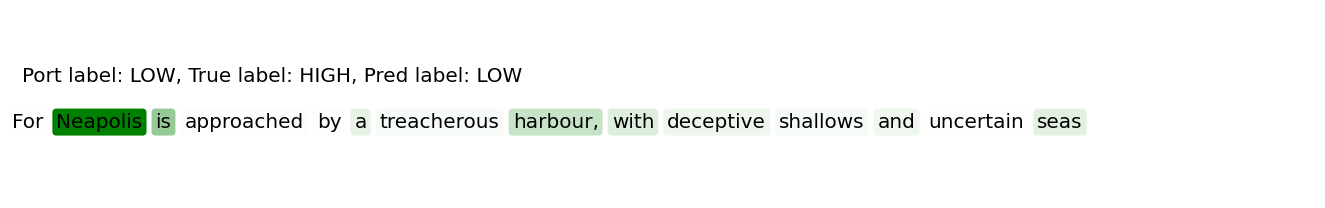

text             For Rhacotis is approached by a treacherous ha...
newOBJECTID                                                     11
real                                                             0
port_label                                                    HIGH
popular                                                          1
true_label                                                    HIGH
label_reg                                                     HIGH
label_roberta                                                 HIGH
Name: 2, dtype: object


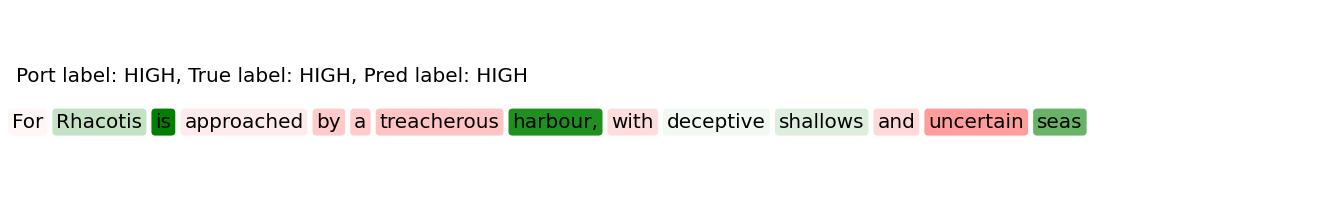

text             sacrificing in the temple of Castor and Pollux...
newOBJECTID                                                     11
real                                                             0
port_label                                                    HIGH
popular                                                          1
true_label                                                     LOW
label_reg                                                      LOW
label_roberta                                                  LOW
Name: 7, dtype: object


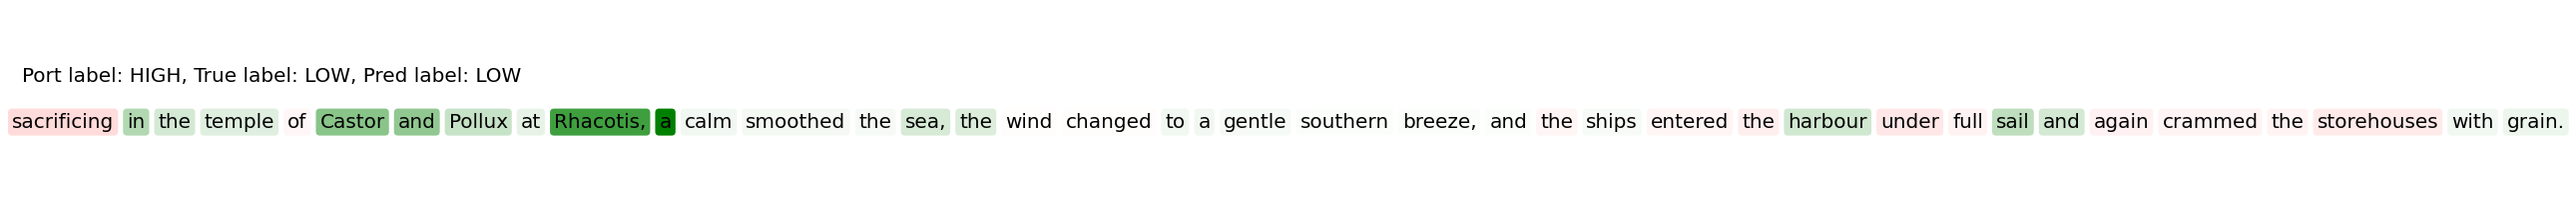

text             sacrificing in the temple of Castor and Pollux...
newOBJECTID                                                    129
real                                                             0
port_label                                                     LOW
popular                                                          1
true_label                                                     LOW
label_reg                                                      LOW
label_roberta                                                  LOW
Name: 9, dtype: object


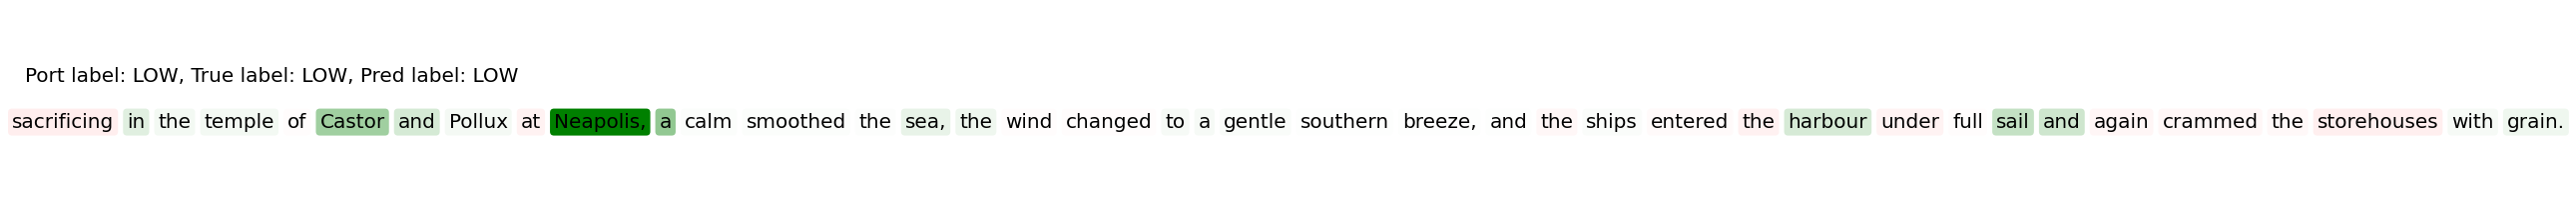

text             sacrificing in the temple of Castor and Pollux...
newOBJECTID                                                      0
real                                                             0
port_label                                                    HIGH
popular                                                          0
true_label                                                     LOW
label_reg                                                     HIGH
label_roberta                                                 HIGH
Name: 6, dtype: object


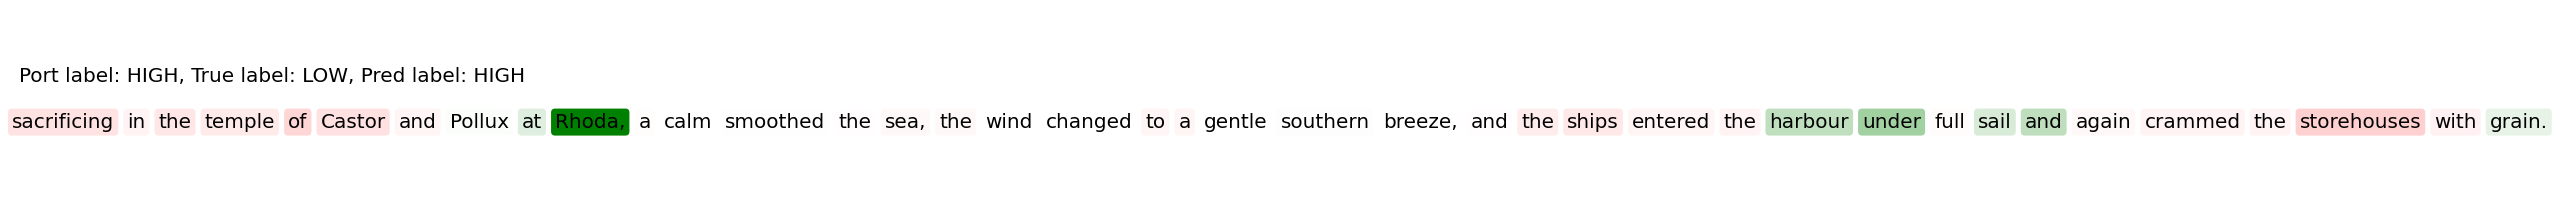

text             For Herculaneum is approached by a treacherous...
newOBJECTID                                                    131
real                                                             0
port_label                                                     LOW
popular                                                          0
true_label                                                    HIGH
label_reg                                                      LOW
label_roberta                                                  LOW
Name: 3, dtype: object


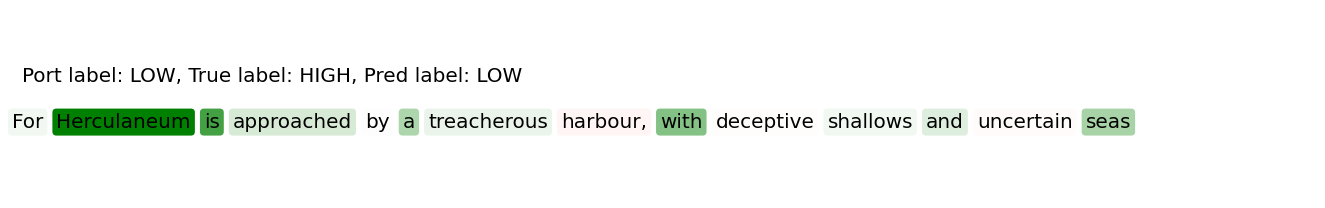

text             For Rhoda is approached by a treacherous harbo...
newOBJECTID                                                      0
real                                                             0
port_label                                                    HIGH
popular                                                          0
true_label                                                    HIGH
label_reg                                                     HIGH
label_roberta                                                 HIGH
Name: 4, dtype: object


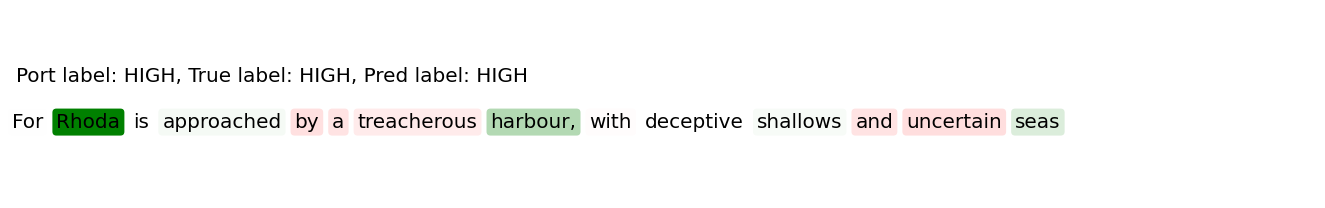

text             sacrificing in the temple of Castor and Pollux...
newOBJECTID                                                    131
real                                                             0
port_label                                                     LOW
popular                                                          0
true_label                                                     LOW
label_reg                                                      LOW
label_roberta                                                  LOW
Name: 8, dtype: object


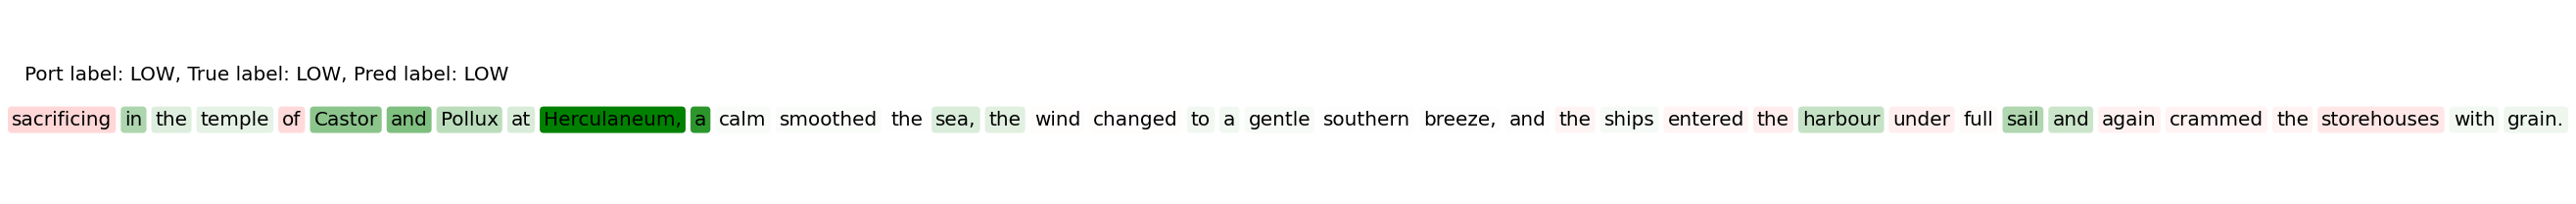

In [38]:
for j in interesting:
    print(df.iloc[j])
    # for i in [2,1,0]:
    i = label2id[df.iloc[j]['label_roberta']]
    tokens, scores = merge_roberta_tokens(data[j], shap_roberta.values[j][:, i])

    # fix length mismatch (due to padding)
    min_len = min(len(tokens), len(scores))
    
    tokens = tokens[:min_len]
    scores = scores[:min_len]
    title = f"Port label: {df.iloc[j]['port_label']}, True label: {df.iloc[j]['true_label']}, Pred label: {df.iloc[j]['label_roberta']}"
    plot_token_attributions(title, tokens, scores, spacing=0.01, fontsize=12)